# **Análisis de Operaciones y Gestión de Inventario**

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [3]:
# Cargar datos
ruta = os.path.join('..', 'Data', 'TouristAccommodationClean26012026.csv')
df = pd.read_csv(ruta)

Cuál es el impacto que tiene la opción de reservar automáticamente ( sin la revisión del propietario) a la disponibilidad media a cada ciudad?

In [4]:
availability_cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365"
]

# Disponibilidad media por ciudad y tipo de reserva
impacto_instant = (
    df
    .groupby(["city", "is_instant_bookable"])[availability_cols]
    .mean()
    .round(2)
    .reset_index()
)

impacto_instant.head(3)

# Separar etiquetas legibles
impacto_instant["tipo_reserva"] = impacto_instant["is_instant_bookable"].map({
    True: "Reserva automática",
    False: "Requiere aprobación"
})

# Crear tabla pivote
tabla_final = impacto_instant.pivot_table(
    index="city",
    columns="tipo_reserva",
    values=availability_cols
)

tabla_final = tabla_final.round(2)
tabla_final



availability_30                       availability_365  \
tipo_reserva Requiere aprobación Reserva automática Requiere aprobación   
city                                                                      
Barcelona                  11.40              10.97              178.49   
Girona                     16.66              13.22              233.78   
Madrid                     10.52              10.92              156.06   
Malaga                     12.70              12.47              199.52   
Mallorca                   13.48              13.55              216.41   
Menorca                    15.67              13.37              214.70   
Sevilla                    13.04              14.67              187.17   
Valencia                   13.65              12.19              187.47   

                                    availability_60                     \
tipo_reserva Reserva automática Requiere aprobación Reserva automática   
city                                                                     
Barcelona                192.57               25.88              25.95   
Girona                   167.42               35.34              28.24   
Madrid                   172.01               23.22              25.90   
Malaga                   205.07               29.06              28.90   
Mallorca                 209.08               29.04              28.81   
Menorca                  178.58               32.08              28.39   
Sevilla                  203.05               28.91              32.10   
Valencia                 174.48               29.88              27.45   

                 availability_90                     
tipo_reserva Requiere aprobación Reserva automática  
city                                                 
Barcelona                  42.46              43.68  
Girona                     54.99              43.36  
Madrid                     37.76              43.06  
Malaga                     48.46              47.58  
Mallorca                   46.12              45.15  
Menorca                    49.11              44.58  
Sevilla                    47.10              51.72  
Valencia                   47.33              45.36

Text(0.5, 0, 'Ciudad')

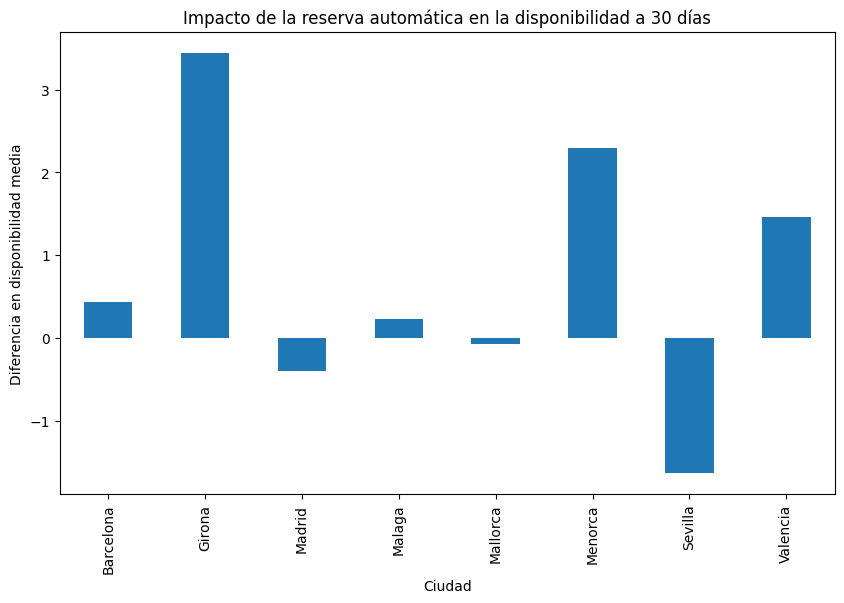

In [5]:
tabla_final["impacto_30"] = (
    tabla_final["availability_30"]["Requiere aprobación"] -
    tabla_final["availability_30"]["Reserva automática"]
).round(2)

tabla_final["impacto_30"].plot(kind="bar", figsize=(10, 6))
plt.title("Impacto de la reserva automática en la disponibilidad a 30 días")
plt.ylabel("Diferencia en disponibilidad media")
plt.xlabel("Ciudad")